# SINDy Testing on Duffing Oscillators

This notebook tests the Sparse Identification of Nonlinear Dynamics (SINDy) algorithm on both single and coupled Duffing oscillators with very low damping.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pysindy as ps
from sklearn.metrics import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

## Single Duffing Oscillator Definition

The Duffing oscillator is defined by the following system of equations:
- dx/dt = y
- dy/dt = -δy - αx - βx³ + γcos(ωt)

Where:
- δ: damping coefficient (very small)
- α: linear restoring force coefficient
- β: nonlinear restoring force coefficient
- γ: driving amplitude
- ω: driving frequency

In [15]:
def single_duffing_oscillator(state, t, alpha, beta, delta):
    """
    Single Duffing oscillator with very low damping
    dx/dt = y
    dy/dt = -delta*y - alpha*x - beta*x^3 
    """
    x, y = state
    dxdt = y
    dydt = -delta * y - alpha * x - beta * x**3 
    return [dxdt, dydt]

## Test SINDy on Single Duffing Oscillator

We'll test different threshold values to see how they affect the discovery of the underlying equations.

## SINDy Optimization Methods Comparison

We'll test different sparsity-promoting optimization methods available in PySINDy:

1. **STLSQ** (Sequential Thresholded Least Squares): Standard method with hard thresholding
2. **SR3** (Sparse Relaxed Regularized Regression): Uses L1 regularization with relaxation  
3. **FROLS** (Forward Regression Orthogonal Least Squares): Greedy forward selection
4. **SINDyPI** (SINDy with Pareto-efficient Identification): Multi-objective optimization (if available)

Each method has different strengths in handling noise, sparsity, and computational efficiency.

Testing SINDy on Single Duffing Oscillator with Low Damping
True parameters: alpha=1.0, beta=1.0, delta=0.001
Data shape: (8000, 2)
Variables: [position, velocity]

==================== STLSQ (threshold=0.0001) ====================
Discovered equations:
(x0)' = 0.999 x1
(x1)' = -0.003 1 + -0.631 x0 + -0.001 x1 + -0.999 x0^3

Significant coefficients (|coeff| >  (threshold=0.0001)):
Total significant coefficients: 6
Mean Squared Error: 157.956284


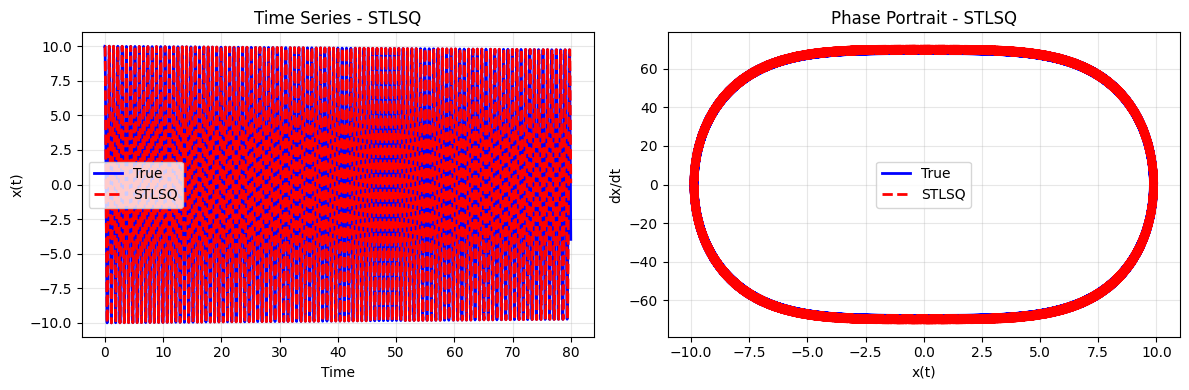


==================== STLSQ (threshold=0.0005) ====================
Discovered equations:
(x0)' = 0.999 x1
(x1)' = -0.002 1 + -1.764 x0 + -0.001 x1 + -0.988 x0^3

Significant coefficients (|coeff| >  (threshold=0.0005)):
Total significant coefficients: 5
Mean Squared Error: 212.150339


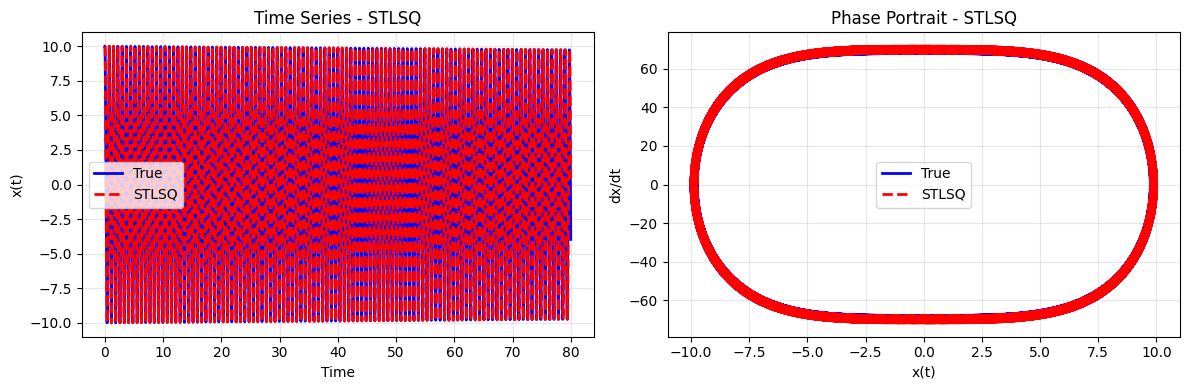


==================== STLSQ (threshold=0.0008) ====================
Discovered equations:
(x0)' = 0.999 x1
(x1)' = -0.002 1 + -1.764 x0 + -0.001 x1 + -0.988 x0^3

Significant coefficients (|coeff| >  (threshold=0.0008)):
Total significant coefficients: 5
Mean Squared Error: 212.150339


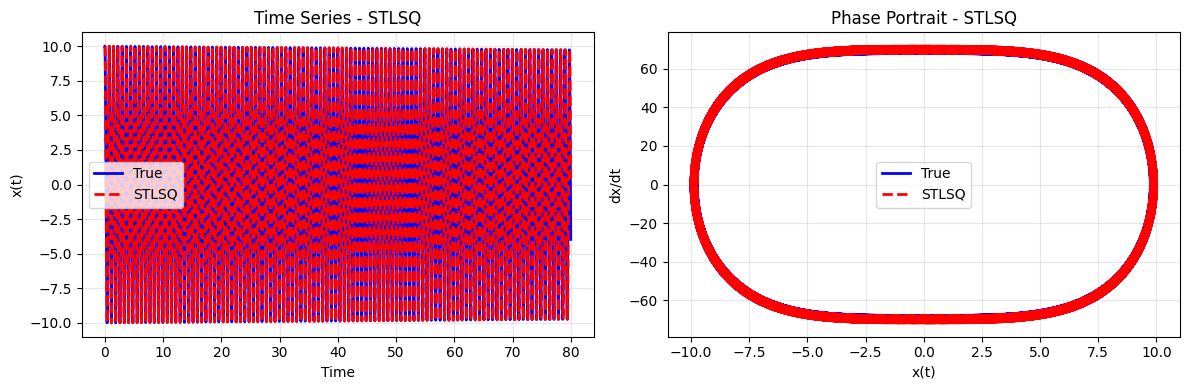


==================== SR3 (threshold=0.0001) ====================
Discovered equations:
(x0)' = 0.999 x1
(x1)' = 0.001 1 + -0.631 x0 + -0.001 x1 + -0.999 x0^3

Significant coefficients (|coeff| >  (threshold=0.0001)):
Total significant coefficients: 6


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


KeyboardInterrupt: 

In [37]:
def test_simple_duffing():
    """Test SINDy on simple Duffing oscillator with different optimizers"""
    print("Testing SINDy on Single Duffing Oscillator with Low Damping")
    print("=" * 60)

    # Parameters
    alpha = 1.0      # linear restoring force
    beta = 1.0       # nonlinear restoring force
    delta = 1e-3    # very low damping coefficient

    print(f"True parameters: alpha={alpha}, beta={beta}, delta={delta}")

    # Time points
    dt = 0.01
    t = np.arange(0, 80, dt)

    # Initial conditions
    initial_conditions = [10.0, 5.0]

    # Generate data
    args = (alpha, beta, delta)
    solution = odeint(single_duffing_oscillator, initial_conditions, t, args=args)

    # Use full state space data (position and velocity)
    x_data = solution  # Shape: (n_samples, 2) - [position, velocity]

    # Add small amount of noise
    noise_level = 0.0
    x_noisy = x_data + noise_level * np.random.normal(size=x_data.shape)

    print(f"Data shape: {x_noisy.shape}")
    print("Variables: [position, velocity]")

    # Test different sparsity-promoting optimizers (using most stable ones)
    optimizers = [
        ("STLSQ", ps.STLSQ(threshold=1e-4)),
        ("STLSQ", ps.STLSQ(threshold=5e-4)),
        ("STLSQ", ps.STLSQ(threshold=8e-4)),
        ("SR3", ps.SR3(threshold=1e-4, thresholder="l1")),
        ("SR3", ps.SR3(threshold=5e-4, thresholder="l1")),
        ("SR3", ps.SR3(threshold=8e-4, thresholder="l1")),

        ("FROLS", ps.FROLS())
    ]

    results = {}
    
    for opt_name, optimizer in optimizers:
        threshold_str = ""
        if hasattr(optimizer, 'threshold'):
            threshold_str = f" (threshold={optimizer.threshold})"
        elif hasattr(optimizer, 'thresholder'):  # For SR3
            if hasattr(optimizer, 'threshold'):
                threshold_str = f" (threshold={optimizer.threshold})"
        
        print(f"\n{'='*20} {opt_name}{threshold_str} {'='*20}")        
        try:
            model = ps.SINDy(
                feature_library=ps.PolynomialLibrary(degree=3),
                optimizer=optimizer,
                differentiation_method=ps.FiniteDifference()
            )

            # Fit the model
            model.fit(x_noisy, t=dt)

            # Print discovered equations
            print("Discovered equations:")
            model.print()

            # Get coefficients
            coeffs = model.coefficients()
            feature_names = model.get_feature_names()

            print(f"\nSignificant coefficients (|coeff| > {threshold_str}):")
            significant_count = 0
            for i, name in enumerate(feature_names):
                for eq_idx in range(coeffs.shape[0]):
                    if abs(coeffs[eq_idx, i]) > float(threshold_str.replace(" (threshold=", "").replace(")", "")):
                        significant_count += 1
            
            print(f"Total significant coefficients: {significant_count}")

            # Test prediction using initial conditions
            x_pred = model.simulate(initial_conditions, t)

            if x_pred is not None and x_pred.shape == solution.shape:
                mse = mean_squared_error(solution, x_pred)
                print(f"Mean Squared Error: {mse:.6f}")
                
                # Store results
                results[opt_name] = {
                    'mse': mse,
                    'n_coeffs': significant_count,
                    'prediction': x_pred,
                    'model': model
                }

                # Plot comparison for first two methods
                if len(results) <= 2:
                    plt.figure(figsize=(12, 4))

                    plt.subplot(1, 2, 1)
                    plt.plot(t[:-1], solution[:-1, 0], 'b-', label='True', linewidth=2)
                    plt.plot(t[:-1], x_pred[:-1, 0], 'r--', label=f'{opt_name}', linewidth=2)
                    plt.xlabel('Time')
                    plt.ylabel('x(t)')
                    plt.title(f'Time Series - {opt_name}')
                    plt.legend()
                    plt.grid(True, alpha=0.3)

                    plt.subplot(1, 2, 2)
                    plt.plot(solution[:-1, 0], solution[:-1, 1], 'b-', label='True', linewidth=2)
                    plt.plot(x_pred[:-1, 0], x_pred[:-1, 1], 'r--', label=f'{opt_name}', linewidth=2)
                    plt.xlabel('x(t)')
                    plt.ylabel('dx/dt')
                    plt.title(f'Phase Portrait - {opt_name}')
                    plt.legend()
                    plt.grid(True, alpha=0.3)

                    plt.tight_layout()
                    plt.savefig(f'duffing_{opt_name.lower()}.png', dpi=150, bbox_inches='tight')
                    plt.show()
            else:
                print("Simulation failed or returned unexpected shape")
                if x_pred is not None:
                    print(f"Expected shape: {solution.shape}, got: {x_pred.shape}")

        except Exception as e:
            print(f"Error with {opt_name}: {str(e)}")
            import traceback
            traceback.print_exc()
    
    # Summary comparison
    if results:
        print(f"\n{'='*60}")
        print("SUMMARY COMPARISON")
        print(f"{'='*60}")
        print(f"{'Method':<15} {'MSE':<15} {'N_Coeffs':<15}")
        print(f"{'-'*45}")
        for method, data in results.items():
            print(f"{method:<15} {data['mse']:<15.6f} {data['n_coeffs']:<15}")
        
        # Find best method
        best_method = min(results.keys(), key=lambda k: results[k]['mse'])
        print(f"\nBest method by MSE: {best_method} (MSE: {results[best_method]['mse']:.6f})")

# Run the test
test_simple_duffing()

## Coupled Duffing Oscillators

Now we'll test SINDy on a system of coupled Duffing oscillators with nearest-neighbor coupling.

In [ ]:
def test_coupled_simple():
    """Test SINDy on simple coupled oscillators"""
    print("\n" + "="*60)
    print("Testing SINDy on Coupled Duffing Oscillators")
    print("=" * 60)

    def coupled_duffing(state, t, n=3, alpha=1.0, beta=1.0, gamma=0.3, delta=1e-5, coupling=0.1):
        """Simple coupled Duffing system"""
        # state = [x1, y1, x2, y2, x3, y3]
        x = state[::2]  # positions
        y = state[1::2]  # velocities

        dxdt = y.copy()
        dydt = np.zeros(n)

        for i in range(n):
            # Individual Duffing dynamics
            dydt[i] = -delta * y[i] - alpha * x[i] - beta * x[i]**3 + gamma * np.cos(t)

            # Simple nearest-neighbor coupling
            if i > 0:
                dydt[i] += coupling * (x[i-1] - x[i])
            if i < n-1:
                dydt[i] += coupling * (x[i+1] - x[i])

        # Interleave derivatives
        derivatives = np.zeros(2*n)
        derivatives[::2] = dxdt
        derivatives[1::2] = dydt
        return derivatives

    # Parameters
    n_nodes = 3
    alpha, beta, gamma = 1.0, 1.0, 0.3
    delta = 1e-5  # very small damping
    coupling = 0.1

    print(f"System: {n_nodes} coupled oscillators, damping={delta}")

    # Time and initial conditions
    dt = 0.01
    t = np.arange(0, 30, dt)
    initial_conditions = [0.1*(i+1) for i in range(n_nodes)] + [0.0]*n_nodes  # [x1,x2,x3,y1,y2,y3]

    # Generate data
    solution = odeint(coupled_duffing, initial_conditions, t,
                     args=(n_nodes, alpha, beta, gamma, delta, coupling))

    # Use only positions for SINDy
    x_data = solution[:, ::2]  # positions only

    # Add noise
    noise_level = 0.005
    x_noisy = x_data + noise_level * np.random.normal(size=x_data.shape)

    print(f"Data shape: {x_noisy.shape}")

    try:
        model = ps.SINDy(
            feature_library=ps.PolynomialLibrary(degree=3, include_interaction=True),
            optimizer=ps.STLSQ(threshold=0.02),
            differentiation_method=ps.FiniteDifference()
        )

        model.fit(x_noisy, t=dt)

        print("Discovered equations:")
        model.print()

        # Show coefficients
        coeffs = model.coefficients()
        feature_names = model.get_feature_names()

        print("\nSignificant coefficients:")
        for eq_idx in range(coeffs.shape[0]):
            print(f"Equation {eq_idx + 1}:")
            for feat_idx, name in enumerate(feature_names):
                if abs(coeffs[eq_idx, feat_idx]) > 1e-3:
                    print(f"  {name}: {coeffs[eq_idx, feat_idx]:.4f}")

        # Test prediction
        x_pred = model.simulate(x_noisy[0], t)
        if x_pred is not None:
            mse = mean_squared_error(x_data, x_pred)
            print(f"\nMSE: {mse:.6f}")

            # Plot first two oscillators
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            axes[0].plot(t[:1000], x_data[:1000, 0], 'b-', label='True', linewidth=2)
            axes[0].plot(t[:1000], x_pred[:1000, 0], 'r--', label='SINDy', linewidth=2)
            axes[0].set_xlabel('Time')
            axes[0].set_ylabel('x₁(t)')
            axes[0].set_title('Oscillator 1')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            axes[1].plot(t[:1000], x_data[:1000, 1], 'b-', label='True', linewidth=2)
            axes[1].plot(t[:1000], x_pred[:1000, 1], 'r--', label='SINDy', linewidth=2)
            axes[1].set_xlabel('Time')
            axes[1].set_ylabel('x₂(t)')
            axes[1].set_title('Oscillator 2')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.savefig('coupled_duffing_simple.png', dpi=150, bbox_inches='tight')
            plt.show()

    except Exception as e:
        print(f"Error in coupled test: {str(e)}")
        import traceback
        traceback.print_exc()

# Run the test
test_coupled_simple()